In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from tabulate import tabulate

df = pd.read_csv("/kaggle/input/datasets/phyothaw/apple-stock-price-prediction-5yr-historical-data/apple_stock_enriched_phase2_output.csv")
df.head()

,Title,Date,Link,Source,Open,High,Low,Close,Volume,Dividends,...,ATR,ADX,gpt_summary,gpt_sentiment_direction,gpt_sentiment_score,gpt_positive_score,gpt_negative_score,gpt_event_type,gpt_relevance_to_apple,gpt_importance_score
0,iPhone - Apple Newsroom,2007-01-09 23:23:21+00:00,https://news.google.com/rss/articles/CBMiQ0FVX...,Google RSS,2.601592,2.798103,2.562470,2.785764,3349298400,0.0,...,0.088980,33.721273,"Apple announced the launch of the new iPhone, ...",Positive,0.90,0.90,0.10,Product,0.95,0.85
1,Apple Events - Apple Newsroom,2010-07-04 21:57:14+00:00,https://news.google.com/rss/articles/CBMiS0FVX...,Google RSS,7.538144,7.551386,7.318762,7.431313,693842800,0.0,...,0.240281,20.790607,Apple has announced that it will be hosting a ...,Positive,0.85,0.85,0.15,Product,0.95,0.90
2,MacBook Pro - Apple Newsroom,2012-06-11 19:58:27+00:00,https://news.google.com/rss/articles/CBMiSkFVX...,Google RSS,17.686608,17.710081,17.172309,17.188560,591264800,0.0,...,0.433893,14.931799,Apple has announced the release of a new MacBo...,Positive,0.85,0.85,0.15,Product,0.90,0.85
3,Mac mini - Apple Newsroom,2012-10-24 14:03:37+00:00,https://news.google.com/rss/articles/CBMiRkFVX...,Google RSS,18.781662,18.936100,18.455255,18.642334,558527200,0.0,...,0.466293,29.939219,Apple has announced the release of a new Mac m...,Positive,0.90,0.90,0.10,Product,0.90,0.85
4,Inclusion & Diversity - Apple Newsroom,2014-08-12 20:58:05+00:00,https://news.google.com/rss/articles/CBMiR0FVX...,Google RSS,21.271840,21.457891,21.176600,21.256336,135180000,0.0,...,0.336273,18.942137,Apple has announced a new $200 million fund to...,Positive,0.85,0.85,0.15,Other,0.90,0.85


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6415 entries, 0 to 6414
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    6415 non-null   object 
 1   Date                     6415 non-null   object 
 2   Link                     6415 non-null   object 
 3   Source                   6415 non-null   object 
 4   Open                     6415 non-null   float64
 5   High                     6415 non-null   float64
 6   Low                      6415 non-null   float64
 7   Close                    6415 non-null   float64
 8   Volume                   6415 non-null   int64  
 9   Dividends                6415 non-null   float64
 10  Stock Splits             6415 non-null   float64
 11  SMA_50                   6415 non-null   float64
 12  SMA_200                  6415 non-null   float64
 13  EMA_50                   6415 non-null   float64
 14  EMA_200                 

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df = df.sort_values("Date").reset_index(drop=True)

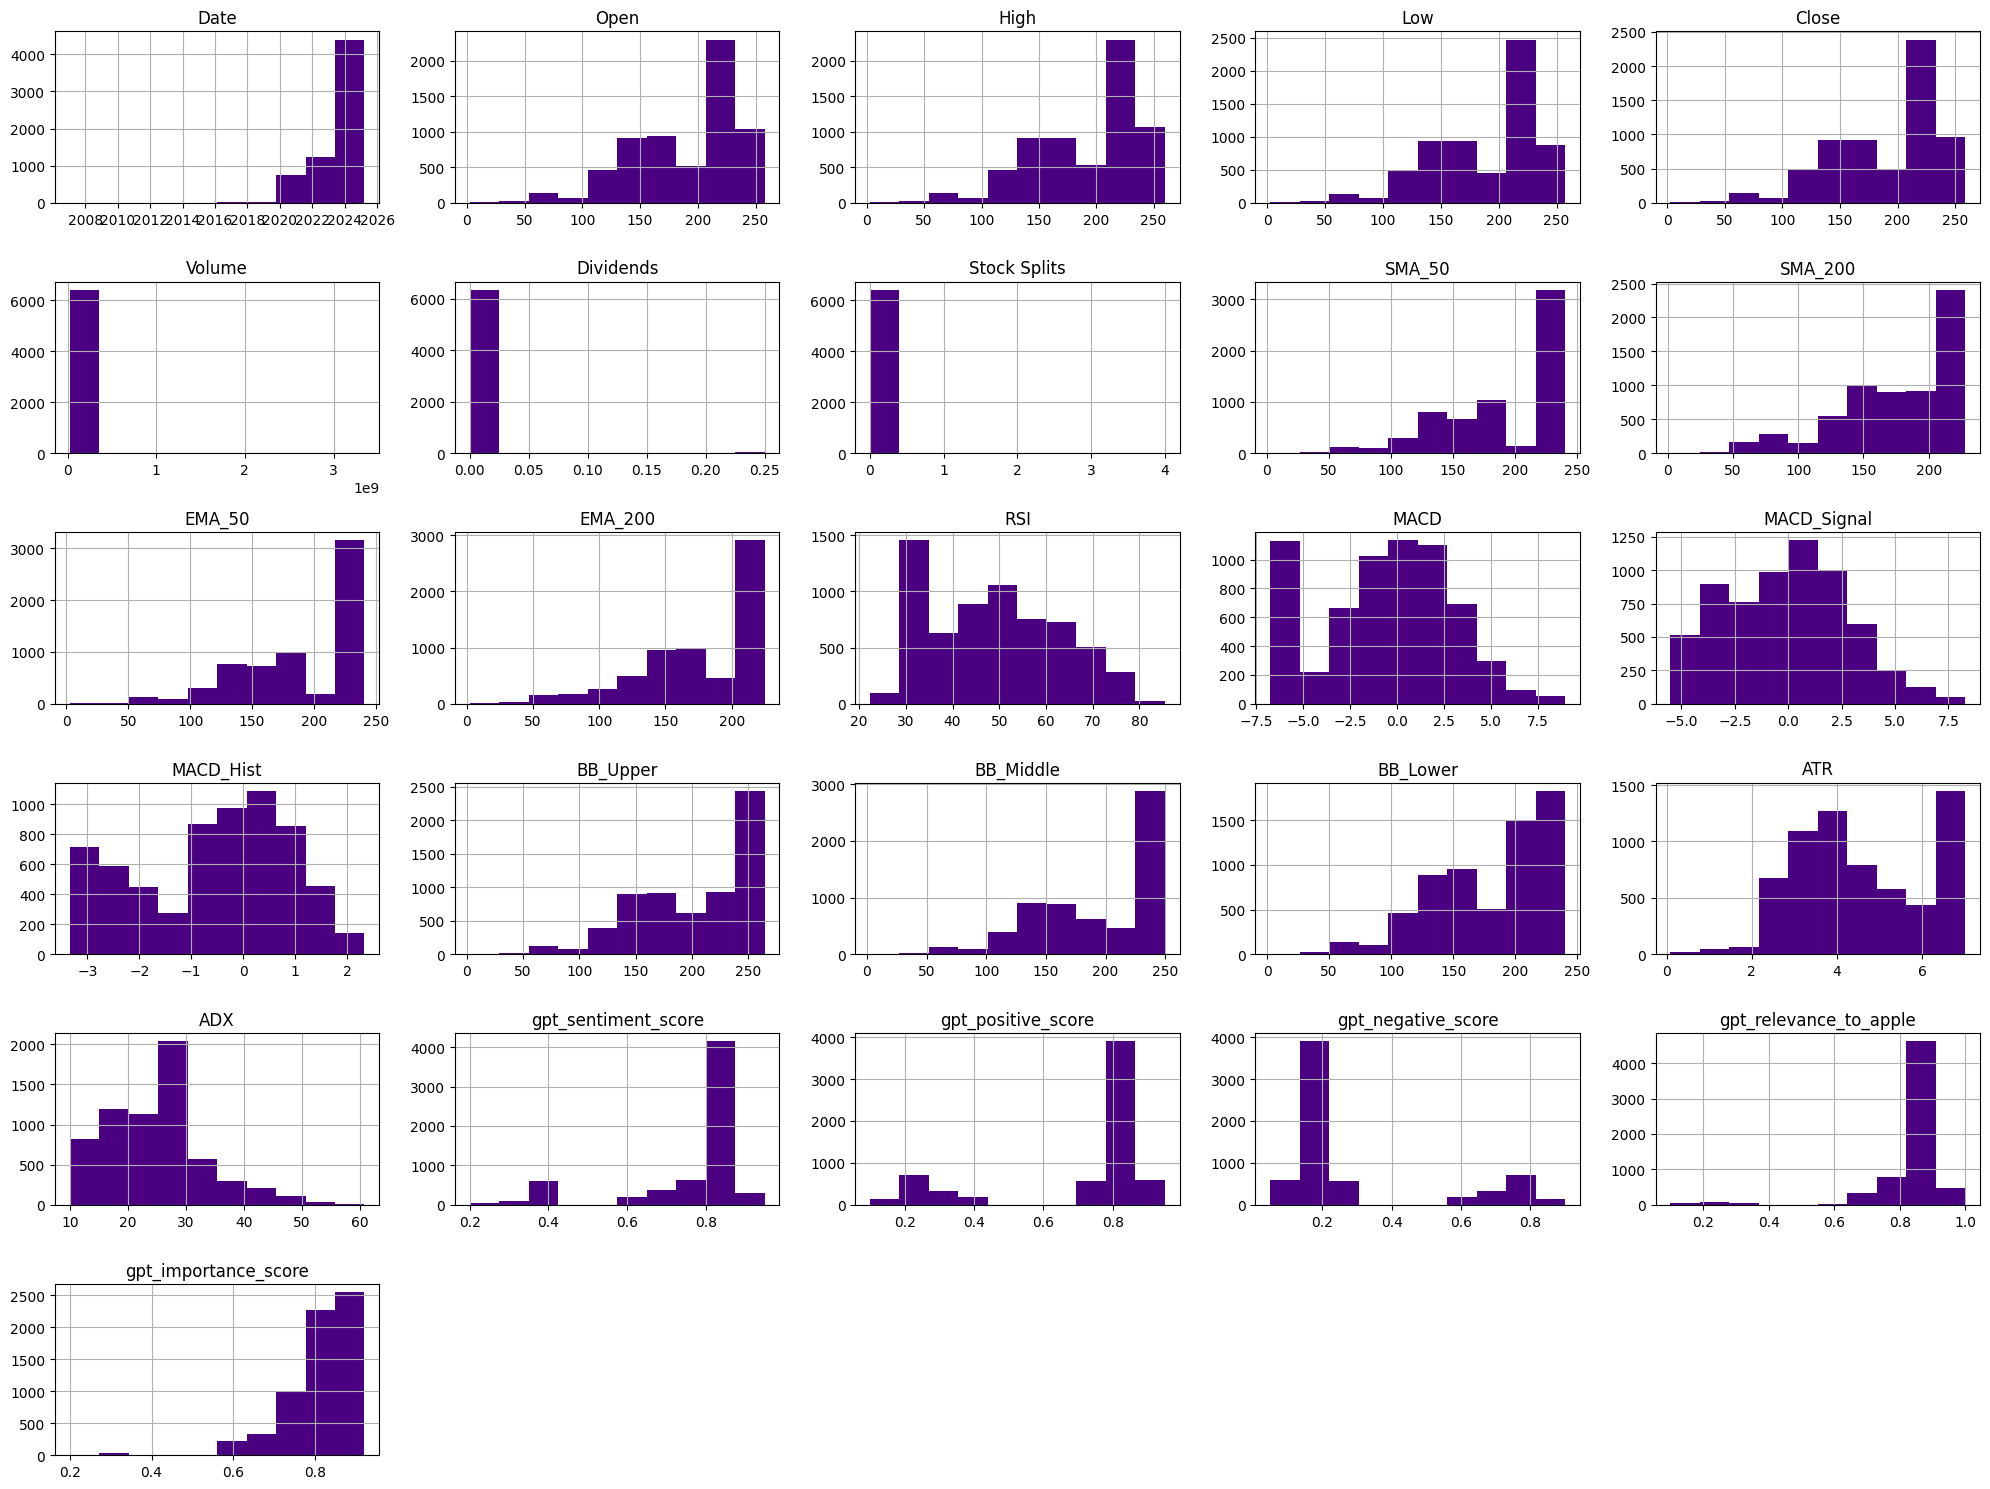

In [5]:
df.hist(figsize=(20,15), bins=10, color='indigo')
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'gpt_sentiment_score'}>,
        <Axes: title={'center': 'gpt_positive_score'}>,
        <Axes: title={'center': 'gpt_negative_score'}>],
       [<Axes: title={'center': 'gpt_importance_score'}>,
        <Axes: title={'center': 'gpt_relevance_to_apple'}>,
        <Axes: title={'center': 'RSI'}>],
       [<Axes: title={'center': 'MACD'}>,
        <Axes: title={'center': 'MACD_Hist'}>,
        <Axes: title={'center': 'Volume'}>],
       [<Axes: title={'center': 'Close'}>, <Axes: >, <Axes: >]],
      dtype=object)

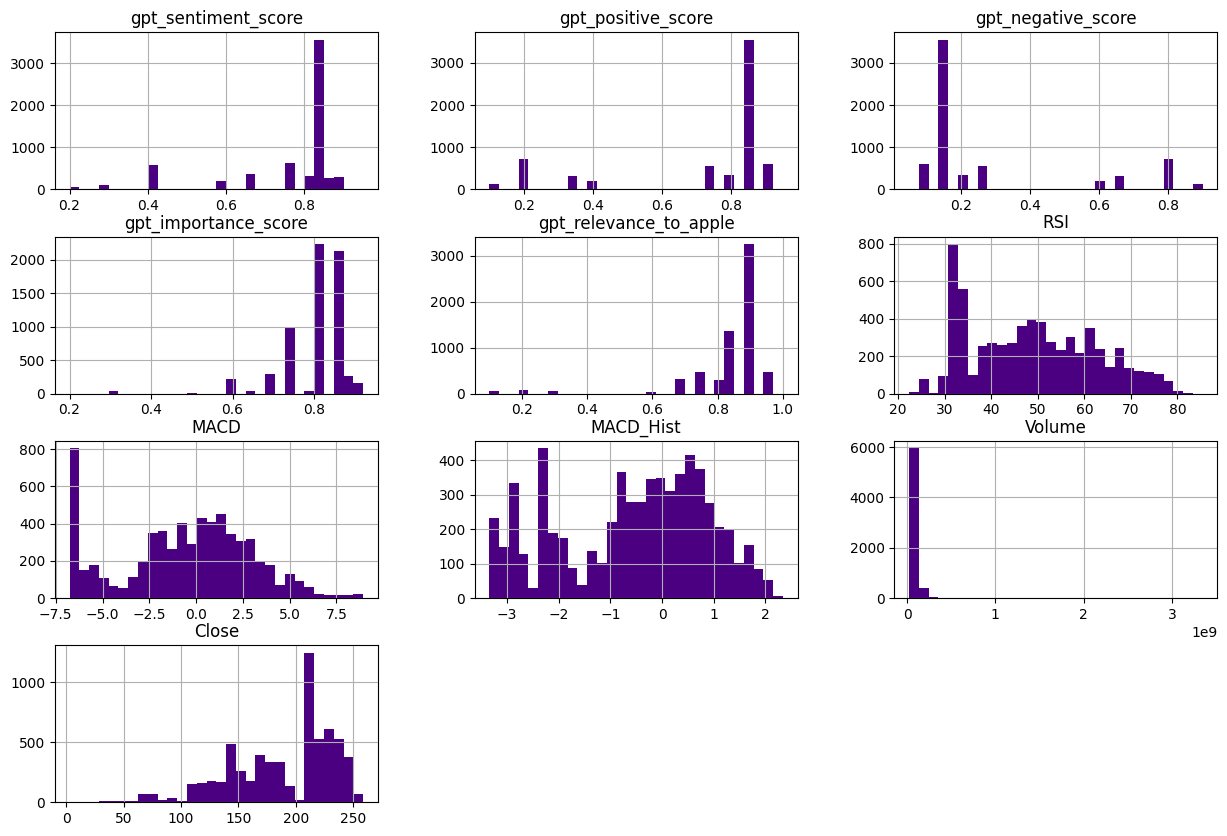

In [6]:
df[[
    "gpt_sentiment_score", "gpt_positive_score", "gpt_negative_score",
    "gpt_importance_score", "gpt_relevance_to_apple",
    "RSI", "MACD", "MACD_Hist", "Volume", "Close"
]].hist(figsize=(15, 10), bins=30, color='indigo')


In [7]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_50,SMA_200,EMA_50,...,BB_Upper,BB_Middle,BB_Lower,ATR,ADX,gpt_sentiment_score,gpt_positive_score,gpt_negative_score,gpt_relevance_to_apple,gpt_importance_score
count,6415.000000,6415.000000,6415.000000,6415.000000,6.415000e+03,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,...,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000
mean,189.341335,191.425654,187.196573,189.307935,7.301673e+07,0.002464,0.001871,191.548327,179.457543,190.989399,...,204.922154,192.509189,180.096223,4.557334,24.946596,0.764868,0.716633,0.283367,0.843595,0.801894
std,45.133448,45.467503,44.586510,44.955826,6.030155e+07,0.024220,0.086488,48.175300,46.602038,47.808564,...,52.131317,48.056652,44.652937,1.470495,8.408056,0.160686,0.246556,0.246556,0.132648,0.074741
min,2.601592,2.798103,2.562470,2.785764,2.323470e+07,0.000000,0.000000,2.575001,2.139975,2.536140,...,2.751056,2.575109,2.399162,0.088980,9.891966,0.200000,0.100000,0.050000,0.100000,0.200000
25%,154.545811,155.747738,152.036458,153.912216,4.801330e+07,0.000000,0.000000,154.175806,150.785042,152.522717,...,164.534158,154.007906,143.420054,3.319865,18.607162,0.750000,0.750000,0.150000,0.850000,0.780000
50%,211.250000,213.949997,209.580002,212.690002,5.937500e+07,0.000000,0.000000,212.253434,188.762177,211.931633,...,230.353916,222.719859,203.571852,4.275861,25.592157,0.850000,0.850000,0.150000,0.900000,0.820000
75%,223.809998,225.839996,221.994983,223.983734,8.222550e+07,0.000000,0.000000,233.455149,223.910876,232.604933,...,253.157259,232.457500,218.551446,6.078266,28.569301,0.850000,0.850000,0.250000,0.900000,0.850000
max,257.906429,259.814335,257.347047,258.735504,3.349298e+09,0.250000,4.000000,240.485810,227.948397,240.882988,...,264.405561,249.710449,240.302475,7.011365,60.755189,0.950000,0.950000,0.900000,1.000000,0.920000


In [8]:
df_missing = (df.isnull().mean() * 100).round(2)
print(df_missing)

Title                      0.0
Date                       0.0
Link                       0.0
Source                     0.0
Open                       0.0
High                       0.0
Low                        0.0
Close                      0.0
Volume                     0.0
Dividends                  0.0
Stock Splits               0.0
SMA_50                     0.0
SMA_200                    0.0
EMA_50                     0.0
EMA_200                    0.0
RSI                        0.0
MACD                       0.0
MACD_Signal                0.0
MACD_Hist                  0.0
BB_Upper                   0.0
BB_Middle                  0.0
BB_Lower                   0.0
ATR                        0.0
ADX                        0.0
gpt_summary                0.0
gpt_sentiment_direction    0.0
gpt_sentiment_score        0.0
gpt_positive_score         0.0
gpt_negative_score         0.0
gpt_event_type             0.0
gpt_relevance_to_apple     0.0
gpt_importance_score       0.0
dtype: f

In [9]:
df.columns

Index(['Title', 'Date', 'Link', 'Source', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Dividends', 'Stock Splits', 'SMA_50', 'SMA_200', 'EMA_50',
       'EMA_200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'ADX', 'gpt_summary',
       'gpt_sentiment_direction', 'gpt_sentiment_score', 'gpt_positive_score',
       'gpt_negative_score', 'gpt_event_type', 'gpt_relevance_to_apple',
       'gpt_importance_score'],
      dtype='object')

In [10]:
print("Duplicates:", df.duplicated().sum())
duplicates = df[df.duplicated()]
print(f"Total Duplicates: {len(duplicates)}")
duplicates

Duplicates: 2
Total Duplicates: 2


,Title,Date,Link,Source,Open,High,Low,Close,Volume,Dividends,...,ATR,ADX,gpt_summary,gpt_sentiment_direction,gpt_sentiment_score,gpt_positive_score,gpt_negative_score,gpt_event_type,gpt_relevance_to_apple,gpt_importance_score
414,Introducing the next generation of Mac - Apple...,2020-11-10 08:00:00+00:00,https://news.google.com/rss/articles/CBMiiAFBV...,Google RSS,112.867044,114.859671,111.480009,113.27729,138023400,0.0,...,4.084511,15.207292,Apple has announced the launch of the next gen...,Positive,0.85,0.85,0.15,Product,0.9,0.85
418,Introducing the next generation of Mac - Apple...,2020-11-10 08:00:00+00:00,https://news.google.com/rss/articles/CBMiiAFBV...,Google RSS,112.867044,114.859671,111.480009,113.27729,138023400,0.0,...,4.084511,15.207292,Apple has announced the launch of the next gen...,Positive,0.85,0.85,0.15,Product,0.9,0.85


In [11]:
df=df.drop_duplicates()

In [12]:
print("Duplicates:", df.duplicated().sum())
duplicates = df[df.duplicated()]
print(f"Total Duplicates: {len(duplicates)}")
duplicates

Duplicates: 0
Total Duplicates: 0


,Title,Date,Link,Source,Open,High,Low,Close,Volume,Dividends,...,ATR,ADX,gpt_summary,gpt_sentiment_direction,gpt_sentiment_score,gpt_positive_score,gpt_negative_score,gpt_event_type,gpt_relevance_to_apple,gpt_importance_score


In [13]:
df["target"] = np.log(df["Close"].shift(-1)) - np.log(df["Close"])
df = df.dropna(subset=["target"])

In [14]:
features=['Volume','MACD', 'MACD_Hist', 'ATR', 'ADX', 
       'gpt_sentiment_score', 'gpt_positive_score',
       'gpt_negative_score', 'gpt_relevance_to_apple',
       'gpt_importance_score'
]

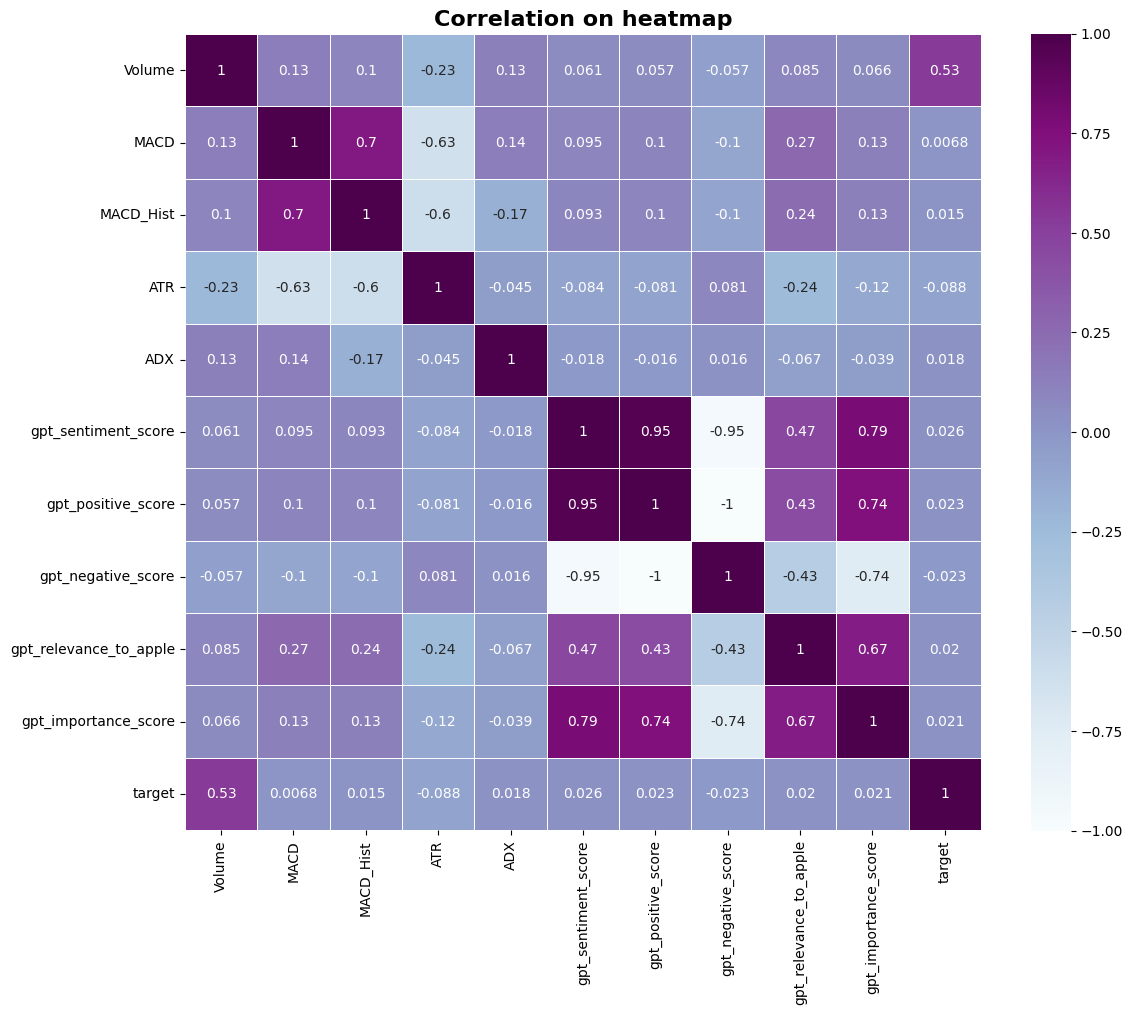

In [15]:
feature_selections= features + ["target"]
cor1=df[feature_selections].corr()
plt.figure(figsize=(12,10))
sb.heatmap(cor1, annot=True, cmap='BuPu', linewidths=0.5, square=True)
plt.title('Correlation on heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
correlations = df[features + ['target']].corr()
print(correlations['target'].sort_values(ascending=False))


target                    1.000000
Volume                    0.531512
gpt_sentiment_score       0.026397
gpt_positive_score        0.023213
gpt_importance_score      0.020676
gpt_relevance_to_apple    0.019837
ADX                       0.017700
MACD_Hist                 0.015012
MACD                      0.006821
gpt_negative_score       -0.023213
ATR                      -0.088033
Name: target, dtype: float64


# Features of Importance

X_train:  (6412, 10)
Y_train:  (6412,)

 Scores of Importances
 [0.3538551  0.031499   0.03491987 0.47138269 0.04152601 0.00797382
 0.00703735 0.00692502 0.01214678 0.03273436]


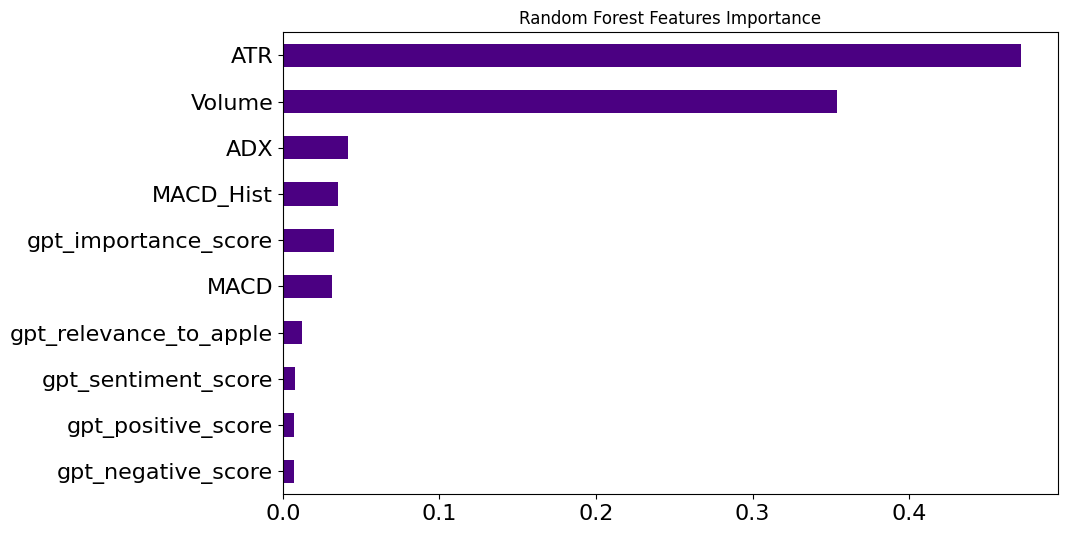

In [17]:
x= df[features]
y= df['target']
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3, random_state=42)
print("X_train: ", x.shape)
print("Y_train: ", y.shape)

rf_imp= RandomForestRegressor(n_estimators=50, random_state=42)
rf_imp.fit(x_train, y_train)

importances = rf_imp.feature_importances_
importances_df = pd.Series(importances, index=features).sort_values()
importances_df.plot (kind='barh', color='indigo', title='Random Forest Features Importance', fontsize='16', figsize=(10,6))
print("\n Scores of Importances\n", importances)

The Random Forest model evaluated the relative importance of various technical and sentiment-based features in predicting Apple’s next-day stock price. The resulting importance plot highlights which features contributed most to the model’s decision-making process.

Key Observations:
ATR (Average True Range) emerged as the most influential feature, indicating that price volatility plays a critical role in next-day price movement prediction.

Volume was the second most important feature, reinforcing the idea that trading activity intensity strongly correlates with price behavior.

Traditional technical indicators such as MACD, MACD_Hist, and ADX also contributed meaningfully, albeit to a lesser extent.

GPT-enriched sentiment features (gpt_sentiment_score, gpt_importance_score, and others) had relatively low influence on the model’s performance, suggesting that while news sentiment adds context, it is not a primary driver for precise short-term price prediction in this setup.

# Permutation Importance


 Permutation Importances:

               Feature  Importance Mean  Importance Std
                   ATR         0.332251        0.033576
  gpt_importance_score         0.038054        0.026027
                  MACD         0.018788        0.013100
                Volume         0.012784        0.012251
             MACD_Hist         0.000389        0.017754
                   ADX        -0.001429        0.008837
gpt_relevance_to_apple        -0.004183        0.001852
   gpt_sentiment_score        -0.006640        0.005693
    gpt_negative_score        -0.007082        0.004494
    gpt_positive_score        -0.008645        0.010152


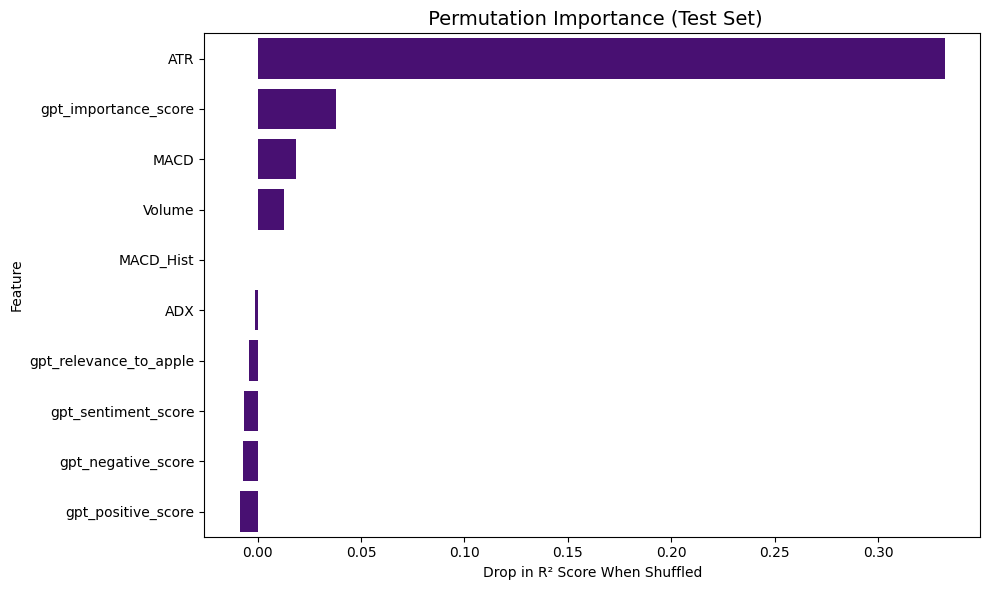

In [18]:
result = permutation_importance(rf_imp, x_test,y_test,n_repeats=10,random_state=42,scoring='r2')
perm_df = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print("\n Permutation Importances:\n")
print(perm_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sb.barplot(x="Importance Mean", y="Feature", data=perm_df, color='indigo')
plt.title(" Permutation Importance (Test Set)", fontsize=14)
plt.xlabel("Drop in R² Score When Shuffled")
plt.tight_layout()
plt.show()


Permutation importance offers a model-agnostic measure of how each feature impacts the predictive power of the model by evaluating the drop in R² score when each feature is randomly shuffled.

Key Insights:
ATR (Average True Range) remains the most impactful feature by a large margin. Shuffling this feature alone causes a significant decline in the model’s R² score, reinforcing its critical role in capturing price volatility.

GPT-enriched gpt_importance_score stands out as the most useful of all sentiment features, ranking second in impact. This suggests that certain context-aware summaries from news data may enhance predictive accuracy, especially when technical signals are less dominant.

MACD and Volume, standard technical indicators, maintain moderate importance but are not as dominant as in feature importance derived from model internals.

Most other sentiment-related features (e.g., gpt_sentiment_score, gpt_positive_score) and indicators like ADX show minimal impact, indicating that their contribution is limited or redundant in the current regression task.

# Random Forest Regressor 


Random Forest Regressor Performance
R² Score: 0.04713198779979788
Mean Absolute Error: 0.004081066796648095
Root Mean Squared Error: 0.012686492849623473
Accuracy Score (Threshold = 0.00): 0.6211018711018711

confusion matrix
 [[1104  640]
 [  89   91]]


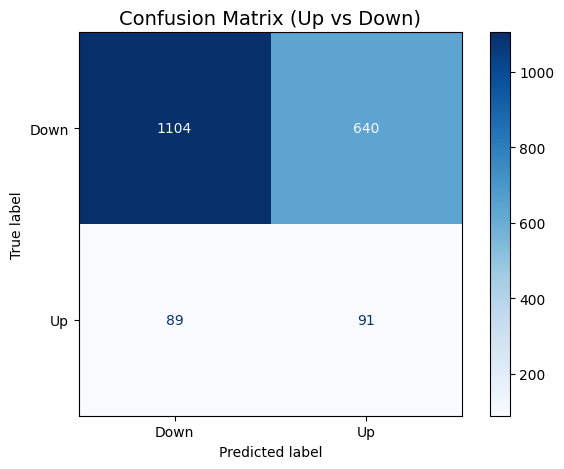

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(x_train, y_train)
y_pred_RF = pipeline.predict(x_test)

threshold = y_train.median()  # or a fixed value like 200
y_test_binary = (y_test > threshold).astype(int)
y_pred_RF_binary = (y_pred_RF > threshold).astype(int)
acc = accuracy_score(y_test_binary, y_pred_RF_binary)

print("\nRandom Forest Regressor Performance")
print("R² Score:", r2_score(y_test, y_pred_RF))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_RF))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_RF)))
print(f"Accuracy Score (Threshold = {threshold:.2f}):", acc)

cm = confusion_matrix(y_test_binary, y_pred_RF_binary)
print("\nconfusion matrix\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix (Up vs Down)", fontsize=14)
plt.tight_layout()
plt.show()

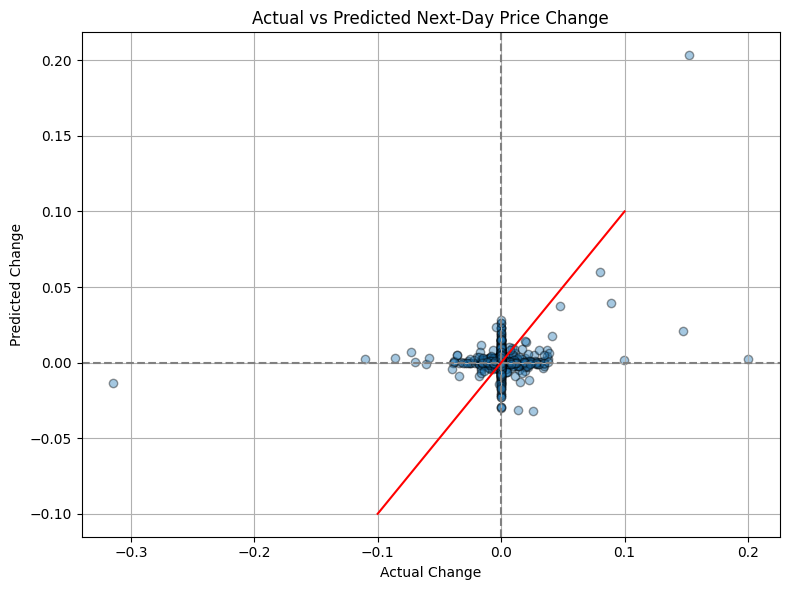

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_RF, alpha=0.4, edgecolors='k')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red')  # Perfect prediction line
plt.title("Actual vs Predicted Next-Day Price Change")
plt.xlabel("Actual Change")
plt.ylabel("Predicted Change")
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Step 1: Copy X_test index back to original DataFrame
df_reset = df.reset_index(drop=True)
Y_test_reset = y_test.reset_index(drop=True)

df_test_result = df_reset.iloc[Y_test_reset.index].copy()
df_test_result["Actual"] = y_test.values
df_test_result["Predicted"] = y_pred_RF

# Step 2: Group by event type
event_impact_df = df_test_result.groupby("gpt_event_type").agg({
    "Actual": ["mean", "count"],
    "Predicted": "mean"
}).reset_index()

# Clean up column names
event_impact_df.columns = ["Event_Type", "Actual_Mean", "Count", "Predicted_Mean"]
event_impact_df = event_impact_df.sort_values(by="Predicted_Mean", ascending=False)

# Step 4: Tabulate format
print("\n Average Price Change by GPT Event Type:")
print(tabulate(event_impact_df, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


 Average Price Change by GPT Event Type:
╒════╤═════════════════════════════════╤═══════════════╤═════════╤══════════════════╕
│    │ Event_Type                      │   Actual_Mean │   Count │   Predicted_Mean │
╞════╪═════════════════════════════════╪═══════════════╪═════════╪══════════════════╡
│  8 │ Social Responsibility           │      0.000000 │       1 │         0.002788 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  4 │ Macro                           │      0.000000 │       5 │         0.001029 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  9 │ Strategy                        │      0.031541 │       1 │         0.000606 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  1 │ Financial                       │     -0.000286 │     524 │         0.000589 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  6 │ Produ

# XGBoost Regressor


XGBoost Regressor Evaluation:
R² Score: -0.20514854740258626
MAE: 0.0042361830153346165
RMSE: 0.014267421636739257
Accuracy Score (Threshold = 0.00): 0.49324324324324326

Confusion Matrix:
 [[863 881]
 [ 94  86]]


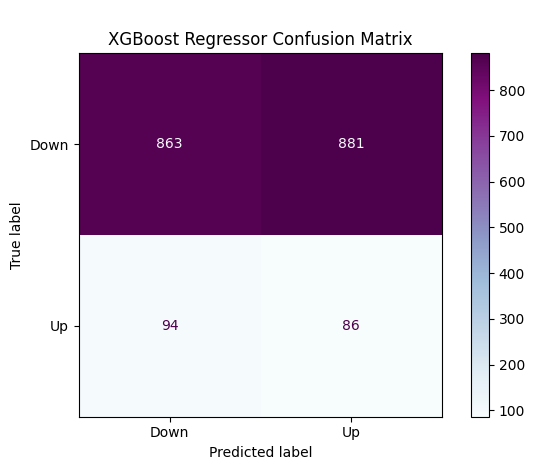

In [22]:
import xgboost as xgb

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(
        n_estimators=50,
        learning_rate=0.2,
        max_depth=10,
        random_state=42,
        objective='reg:squarederror'
    ))
])

xgb_pipeline.fit(x_train, y_train)
y_pred_XGB = xgb_pipeline.predict(x_test)


threshold = y_train.median()  
y_test_binary = (y_test > threshold).astype(int)
y_pred_XGB_binary = (y_pred_XGB > threshold).astype(int)
acc_XGB = accuracy_score(y_test_binary, y_pred_XGB_binary)

print("\nXGBoost Regressor Evaluation:")
print("R² Score:", r2_score(y_test, y_pred_XGB))
print("MAE:", mean_absolute_error(y_test, y_pred_XGB))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_XGB)))
print(f"Accuracy Score (Threshold = {threshold:.2f}):", acc_XGB)

cm = confusion_matrix(y_test_binary, y_pred_XGB_binary)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap='BuPu')
plt.title("\nXGBoost Regressor Confusion Matrix")
plt.tight_layout()
plt.show()


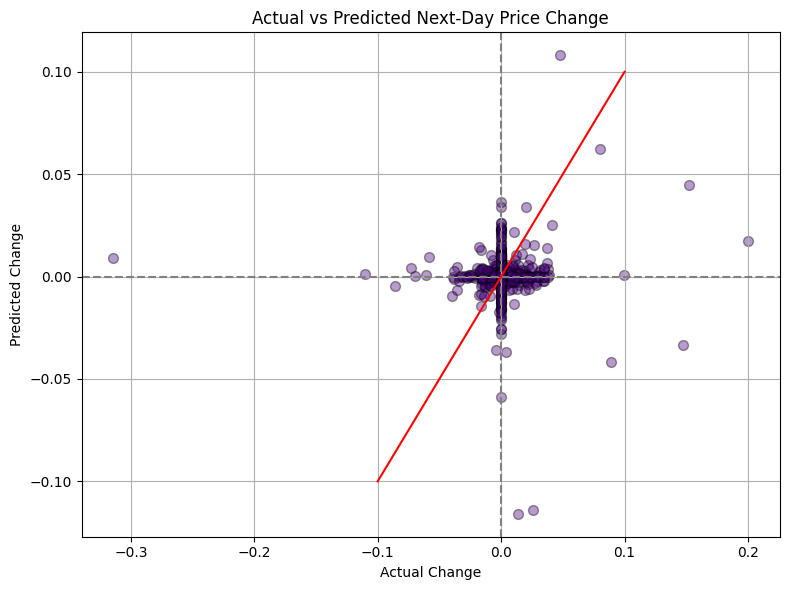

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_XGB, alpha=0.4, edgecolors='k', s=50, c='indigo')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red')  # Perfect prediction line
plt.title("Actual vs Predicted Next-Day Price Change")
plt.xlabel("Actual Change")
plt.ylabel("Predicted Change")
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
# Step 1: Copy X_test index back to original DataFrame
df_reset = df.reset_index(drop=True)
Y_test_reset = y_test.reset_index(drop=True)

df_test_result = df_reset.iloc[Y_test_reset.index].copy()
df_test_result["Actual"] = y_test.values
df_test_result["Predicted"] = y_pred_XGB

# Step 2: Group by event type
event_impact_df = df_test_result.groupby("gpt_event_type").agg({
    "Actual": ["mean", "count"],
    "Predicted": "mean"
}).reset_index()

# Clean up column names
event_impact_df.columns = ["Event_Type", "Actual_Mean", "Count", "Predicted_Mean"]
event_impact_df = event_impact_df.sort_values(by="Predicted_Mean", ascending=False)

# Step 3: Display
print("\nAverage Price Change by GPT Event Type (XGBoost Predictions):")
print(tabulate(event_impact_df, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


Average Price Change by GPT Event Type (XGBoost Predictions):
╒════╤═════════════════════════════════╤═══════════════╤═════════╤══════════════════╕
│    │ Event_Type                      │   Actual_Mean │   Count │   Predicted_Mean │
╞════╪═════════════════════════════════╪═══════════════╪═════════╪══════════════════╡
│  9 │ Strategy                        │      0.031541 │       1 │         0.002982 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  0 │ Corporate Social Responsibility │     -0.009667 │       2 │         0.001454 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  5 │ Other                           │     -0.000085 │      51 │         0.000450 │
├────┼─────────────────────────────────┼───────────────┼─────────┼──────────────────┤
│  1 │ Financial                       │     -0.000286 │     524 │         0.000385 │
├────┼─────────────────────────────────┼───────────────┼─────────┼───────────

# *Standard Scaler with Gradient Boosting Regression*

GradientBoostingRegressor Evaluation:
R² Score: 0.08565751252192921
MAE: 0.0034065741786278125
RMSE: 0.01242738221181689
Accuracy Score (Threshold = 0.00): 0.47401247401247404


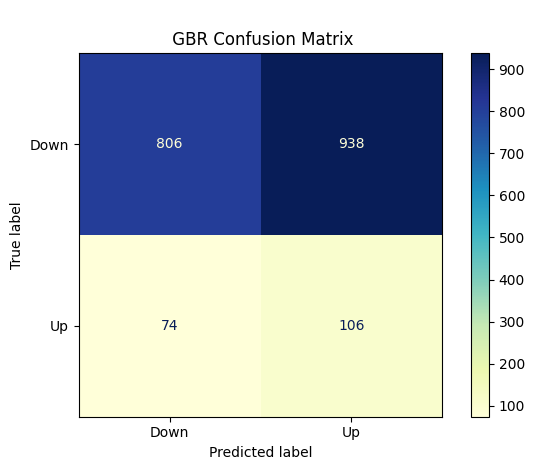

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline


# Replace scaler with PCA
Gradient_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gbr', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

# Train
Gradient_pipeline.fit(x_train, y_train)
y_pred_GBR = Gradient_pipeline.predict(x_test)

threshold = y_train.median()  # or a fixed value like 200
y_test_GBR_class = (y_test > threshold).astype(int)
y_pred_GBR_class = (y_pred_GBR > threshold).astype(int)
acc_GBR = accuracy_score(y_test_GBR_class, y_pred_GBR_class)

# Evaluate
print("GradientBoostingRegressor Evaluation:")
print("R² Score:", r2_score(y_test, y_pred_GBR))
print("MAE:", mean_absolute_error(y_test, y_pred_GBR))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_GBR)))
print(f"Accuracy Score (Threshold = {threshold:.2f}):", acc_GBR)

cm = confusion_matrix(y_test_GBR_class, y_pred_GBR_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap='YlGnBu')
plt.title("\n GBR Confusion Matrix")
plt.tight_layout()
plt.show()


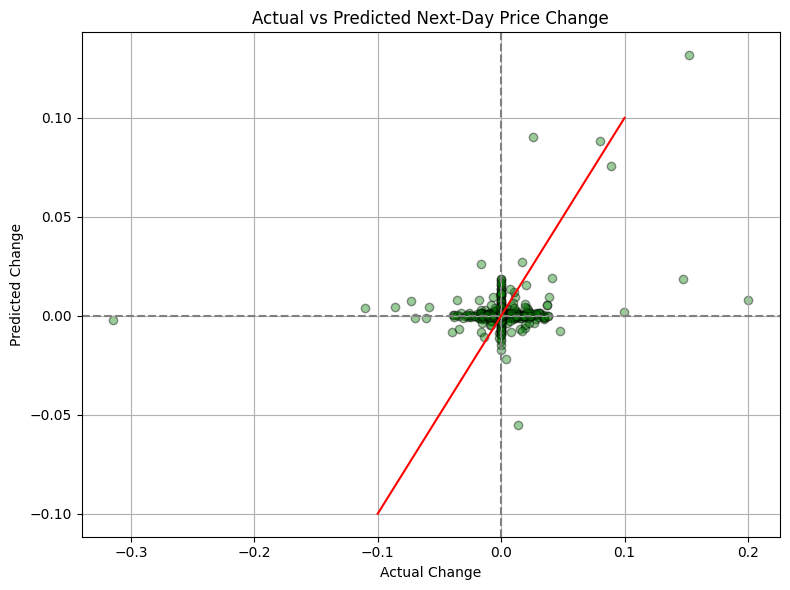

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_GBR, alpha=0.4, edgecolors='k', color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red')  # Perfect prediction line
plt.title("Actual vs Predicted Next-Day Price Change")
plt.xlabel("Actual Change")
plt.ylabel("Predicted Change")
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# Step 1: Copy X_test index back to original DataFrame
df_reset = df.reset_index(drop=True)
Y_test_reset = y_test.reset_index(drop=True)

df_test_result = df_reset.iloc[Y_test_reset.index].copy()
df_test_result["Actual"] = y_test.values
df_test_result["Predicted"] = y_pred_GBR

# Step 2: Group by event type
event_impact_df = df_test_result.groupby("gpt_event_type").agg({
    "Actual": ["mean", "count"],
    "Predicted": "mean"
}).reset_index()

# Clean up column 
event_impact_df.columns = ["Event_Type", "Actual_Mean", "Count", "Predicted_Mean"]
event_impact_df_filtered = event_impact_df[event_impact_df["Count"] > 10].sort_values(by="Predicted_Mean", ascending=False)


# Step 3: Display
print("\nAverage Price Change by GPT Event Type (PCA + Gradiant Boosting Regressor Predictions):")
print(tabulate(event_impact_df_filtered, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))




Average Price Change by GPT Event Type (PCA + Gradiant Boosting Regressor Predictions):
╒════╤══════════════╤═══════════════╤═════════╤══════════════════╕
│    │ Event_Type   │   Actual_Mean │   Count │   Predicted_Mean │
╞════╪══════════════╪═══════════════╪═════════╪══════════════════╡
│  3 │ Legal        │     -0.000060 │      15 │         0.000639 │
├────┼──────────────┼───────────────┼─────────┼──────────────────┤
│  1 │ Financial    │     -0.000286 │     524 │         0.000617 │
├────┼──────────────┼───────────────┼─────────┼──────────────────┤
│  6 │ Product      │      0.000660 │    1314 │         0.000357 │
├────┼──────────────┼───────────────┼─────────┼──────────────────┤
│  5 │ Other        │     -0.000085 │      51 │         0.000317 │
╘════╧══════════════╧═══════════════╧═════════╧══════════════════╛


# *Ridge Regression Evaluation*


Ridge Regression Results:
╒══════════╤════════════╤════════╤════════╕
│    alpha │   R² Score │    MAE │   RMSE │
╞══════════╪════════════╪════════╪════════╡
│   0.0010 │    -0.3409 │ 0.0071 │ 0.0150 │
├──────────┼────────────┼────────┼────────┤
│   0.0100 │    -0.3409 │ 0.0071 │ 0.0150 │
├──────────┼────────────┼────────┼────────┤
│   0.1000 │    -0.3408 │ 0.0071 │ 0.0150 │
├──────────┼────────────┼────────┼────────┤
│   1.0000 │    -0.3407 │ 0.0071 │ 0.0150 │
├──────────┼────────────┼────────┼────────┤
│  10.0000 │    -0.3391 │ 0.0070 │ 0.0150 │
├──────────┼────────────┼────────┼────────┤
│ 100.0000 │    -0.3240 │ 0.0070 │ 0.0150 │
╘══════════╧════════════╧════════╧════════╛

Ridge Regressor Evaluation:
R² Score: -0.32398960313062775
MAE: 0.006950907265212776
RMSE: 0.0149543483311357
Accuracy Score (Threshold = 0.00): 0.6081081081081081


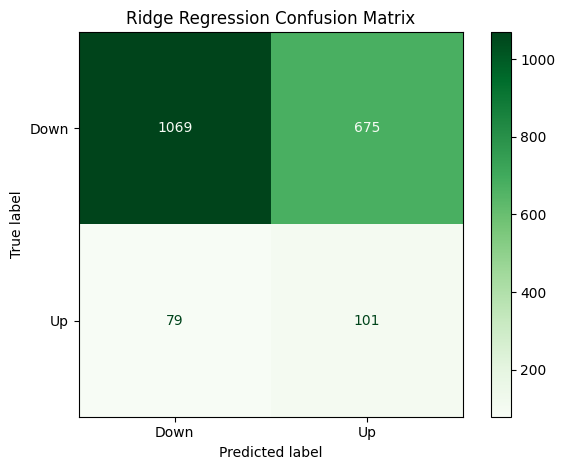

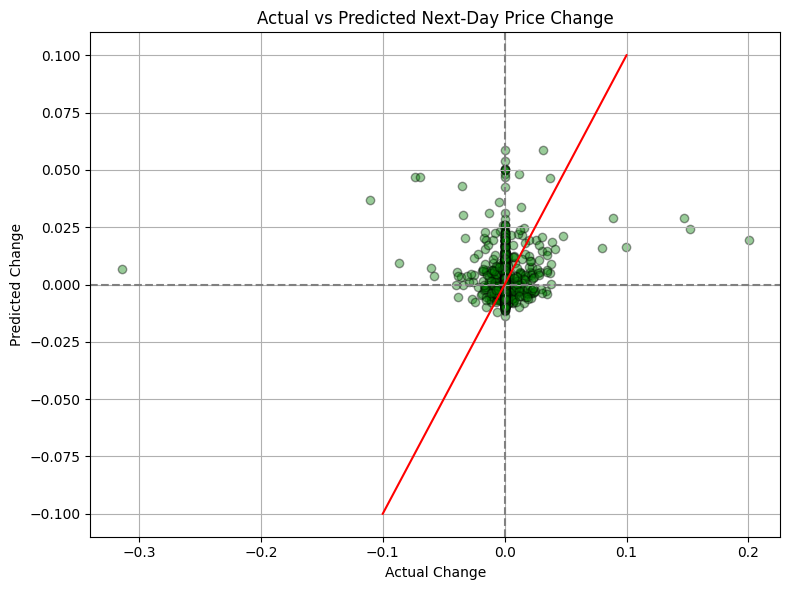

In [28]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = [0.001,0.01,0.1,1,10,100]
results = []
for a in alphas:
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))  # You can tune alpha
    ])

    ridge_pipeline.fit(x_train, y_train)
    y_pred_Ridge = ridge_pipeline.predict(x_test)

    results.append({
        'alpha': a,
        'R² Score': r2_score(y_test, y_pred_Ridge),
        'MAE': mean_absolute_error(y_test, y_pred_Ridge),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_Ridge))
    })


print("\nRidge Regression Results:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".4f"))

threshold = y_train.median()  # or a fixed value like 200
y_test_class = (y_test > threshold).astype(int)
y_pred_Ridge_class = (y_pred_Ridge > threshold).astype(int)
acc_Ridge = accuracy_score(y_test_class, y_pred_Ridge_class)

print("\nRidge Regressor Evaluation:")
print("R² Score:", r2_score(y_test, y_pred_Ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_Ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_Ridge)))
print(f"Accuracy Score (Threshold = {threshold:.2f}):", acc_Ridge)

cm = confusion_matrix(y_test_class, y_pred_Ridge_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap='Greens')
plt.title("Ridge Regression Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_Ridge, alpha=0.4, edgecolors='k', color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red')  # Perfect prediction line
plt.title("Actual vs Predicted Next-Day Price Change")
plt.xlabel("Actual Change")
plt.ylabel("Predicted Change")
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
# Step 1: Copy X_test index back to original DataFrame
df_reset = df.reset_index(drop=True)


df_test_result = df_reset.iloc[Y_test_reset.index].copy()
df_test_result["Actual"] = y_test_binary
df_test_result["Predicted"] = y_pred_Ridge

# Step 2: Group by event type
event_impact_df = df_test_result.groupby("gpt_event_type").agg({
    "Actual": ["mean", "count"],
    "Predicted": "mean"
}).reset_index()

# Clean up column 
event_impact_df.columns = ["Event_Type", "Actual_Mean", "Count", "Predicted_Mean"]
event_impact_df_filtered = event_impact_df[event_impact_df["Count"] > 10].sort_values(by="Predicted_Mean", ascending=False)


# Step 3: Display
print("\nAverage Price Change by GPT Event Type (PCA + Gradiant Boosting Regressor Predictions):")
print(tabulate(event_impact_df_filtered, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))




Average Price Change by GPT Event Type (PCA + Gradiant Boosting Regressor Predictions):
╒════╤══════════════╤═══════════════╤═════════╤══════════════════╕
│    │ Event_Type   │   Actual_Mean │   Count │   Predicted_Mean │
╞════╪══════════════╪═══════════════╪═════════╪══════════════════╡
│  6 │ Product      │      0.171084 │     415 │         0.000935 │
├────┼──────────────┼───────────────┼─────────┼──────────────────┤
│  1 │ Financial    │      0.246835 │     158 │         0.000758 │
├────┼──────────────┼───────────────┼─────────┼──────────────────┤
│  5 │ Other        │      0.150000 │      20 │        -0.001042 │
╘════╧══════════════╧═══════════════╧═════════╧══════════════════╛


# *Linear Regression with Polynomial and Standard Scaler*

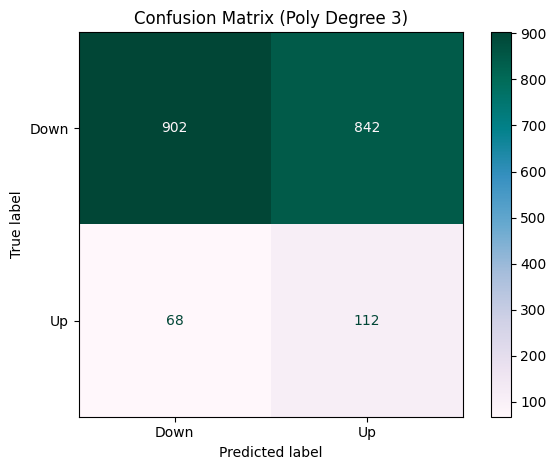


Polynomial Regression Performance Summary:

   Degree  R2 Score       MAE      RMSE  Accuracy
0       1 -0.340862  0.007059  0.015049  0.608628
1       2 -0.140379  0.005301  0.013879  0.521310
2       3 -0.074049  0.004784  0.013469  0.527027


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
degrees = [1, 2, 3]


results = []

threshold = y_train.median()

for degree in degrees:
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])

    # Fit and predict
    poly_pipeline.fit(x_train, y_train)
    y_pred = poly_pipeline.predict(x_test)

    # Classification
    y_test_class = (y_test > threshold).astype(int)
    y_pred_class = (y_pred > threshold).astype(int)
    acc = accuracy_score(y_test_class, y_pred_class)

    # Save evaluation metrics
    results.append({
        'Degree': degree,
        'R2 Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Accuracy': acc
    })

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap='PuBuGn')
plt.title(f"Confusion Matrix (Poly Degree {degree})")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print("\nPolynomial Regression Performance Summary:\n")
print(results_df)

# LSTM model

In [31]:
# def create_sequences(data, target, window_size=10):
#     X, y = [], []
#     for i in range(len(data) - window_size):
#         X.append(data[i:i+window_size])
#         y.append(target[i+window_size])  # predict next day after window
#     return np.array(X), np.array(y)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df[features])
# target = df["target"].values

# X_seq, y_seq = create_sequences(scaled_features, target, window_size=10)
# print("LSTM input shape:", X_seq.shape)  # (samples, timesteps, features)

# split = int(0.7 * len(X_seq))
# X_train, X_test = X_seq[:split], X_seq[split:]
# y_train, y_test = y_seq[:split], y_seq[split:]
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_test shape:", y_test.shape)

In [32]:
# import numpy as np
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout

# model = Sequential([
#     LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(1)
# ])

# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()
# history = model.fit(X_train, y_train, epochs=30, batch_size=20, validation_split=0.2, verbose=1)

# y_lstm = model.predict(X_test).flatten()

# threshold = np.median(y_train)  # or a fixed value like 200
# y_test_class = (y_test > threshold).astype(int)
# y_lstm_class = (y_lstm > threshold).astype(int)
# acc_lstm = accuracy_score(y_test_class, y_lstm_class)

# print("\nLSTM Model Evaluation:")
# print("R² Score:", r2_score(y_test, y_lstm))
# print("MAE:", mean_absolute_error(y_test, y_lstm))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_lstm)))
# print(f"Accuracy Score (Threshold = {threshold:.2f}):", acc_lstm)


# cm = confusion_matrix(y_test_class, y_lstm_class)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
# disp.plot(cmap='Blues')
# plt.title("LSTM Confusion Matrix")
# plt.tight_layout()
# plt.show()

# plt.plot(history.history['loss'], label='train_loss')
# plt.plot(history.history['val_loss'], label='val_loss')
# plt.title('\nLSTM Training Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()